In [41]:
# Importamos las librerías necesarias y cargamos el dataset para explorarlo. En este caso, se ha cargado un archivo CSV de una sesión de vibraciones normales.
# Luego, se muestra la cabeza del DataFrame para tener una idea de cómo son los datos.
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("../data/training/normal/session_20260216_212407.csv")

df.head()

,t_s,sensor_id,vx_um_s,vy_um_s,vz_um_s,dx_um,dy_um,dz_um
0,0.106809,0,8516.0,3091.0,3128.0,0.000000,0.000000,0.000000
1,0.108141,1,5298.0,5792.0,2867.0,0.000000,0.000000,0.000000
2,0.113047,0,8739.0,3159.0,3438.0,52.787245,19.120271,20.086992
3,0.114365,1,5298.0,5792.0,2867.0,32.345921,35.361943,17.503918
4,0.119579,0,8739.0,3159.0,3438.0,107.755058,38.989460,41.724887


In [42]:
# Exploramos las columnas y la forma del DataFrame
print(df.columns)
print(df.shape)

Index(['t_s', 'sensor_id', 'vx_um_s', 'vy_um_s', 'vz_um_s', 'dx_um', 'dy_um',
       'dz_um'],
      dtype='str')
(14592, 8)


In [43]:
# Ahora, filtramos los datos para obtener solo las lecturas del sensor con ID 0 y mostramos la cabeza de este nuevo DataFrame.
sensor0 = df[df["sensor_id"] == 0]

sensor0.head()

,t_s,sensor_id,vx_um_s,vy_um_s,vz_um_s,dx_um,dy_um,dz_um
0,0.106809,0,8516.0,3091.0,3128.0,0.000000,0.000000,0.000000
2,0.113047,0,8739.0,3159.0,3438.0,52.787245,19.120271,20.086992
4,0.119579,0,8739.0,3159.0,3438.0,107.755058,38.989460,41.724887
6,0.126550,0,8739.0,3159.0,3438.0,165.431541,59.837801,64.428146
8,0.133071,0,8951.0,3210.0,3524.0,218.820349,79.054262,85.452654


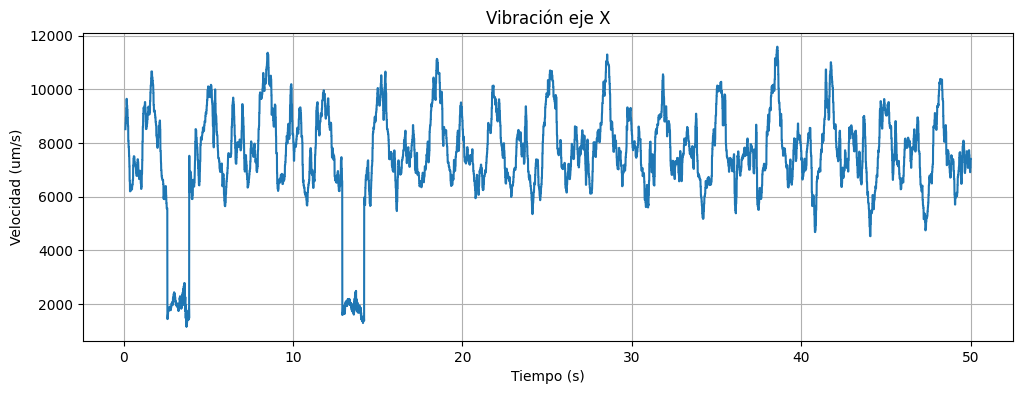

In [44]:
# Graficamos la velocidad en el eje X (vx_um_s) a lo largo del tiempo (t_s) para el sensor 0.
plt.figure(figsize=(12,4))

plt.plot(
    sensor0["t_s"],
    sensor0["vx_um_s"]
)

plt.title("Vibración eje X")
plt.xlabel("Tiempo (s)")
plt.ylabel("Velocidad (um/s)")
plt.grid()

plt.show()

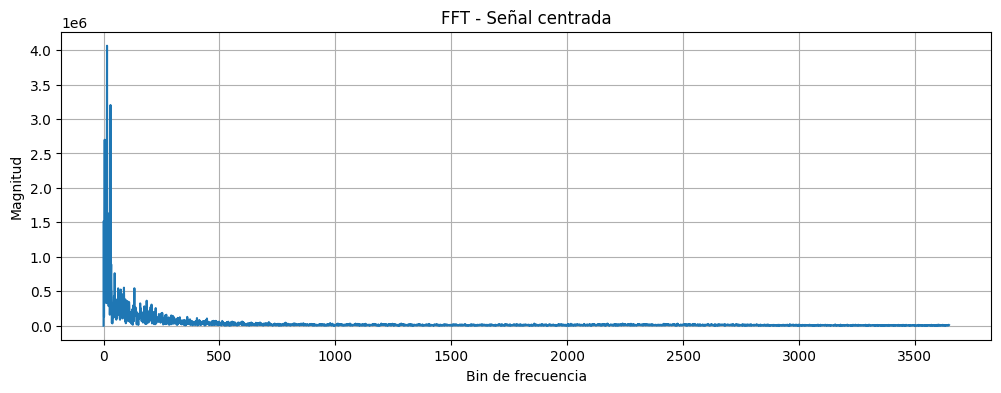

In [45]:
# Realizamos la Transformada Rápida de Fourier (FFT) para analizar las frecuencias presentes en la señal de vibración del sensor 0.
# Primero, se centra la señal eliminando su componente DC (media), y luego se calcula la magnitud de la FFT.
# Finalmente, se grafica la magnitud de la FFT para visualizar las frecuencias dominantes en la señal.
from scipy.fft import fft
import numpy as np
import matplotlib.pyplot as plt

signal = sensor0["vx_um_s"].values

# quitar componente DC
signal = signal - np.mean(signal)

fft_values = np.abs(fft(signal))

plt.figure(figsize=(12,4))

plt.plot(
    fft_values[:len(fft_values)//2]
)

plt.title("FFT - Señal centrada")
plt.xlabel("Bin de frecuencia")
plt.ylabel("Magnitud")

plt.grid(True)

plt.show()

## **Se eliminó previamente la componente continua de la señal mediante centrado respecto a la media. La FFT muestra una componente frecuencial dominante asociada al movimiento rotativo del sistema y componentes adicionales de menor amplitud que representan armónicos y otras contribuciones dinámicas.**

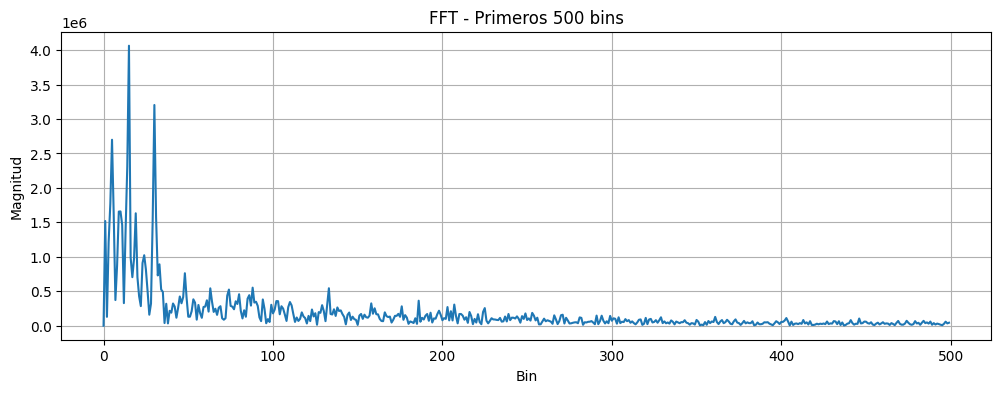

In [46]:
plt.figure(figsize=(12,4))

plt.plot(
    fft_values[:500]
)

plt.title("FFT - Primeros 500 bins")
plt.xlabel("Bin")
plt.ylabel("Magnitud")
plt.grid(True)

plt.show()

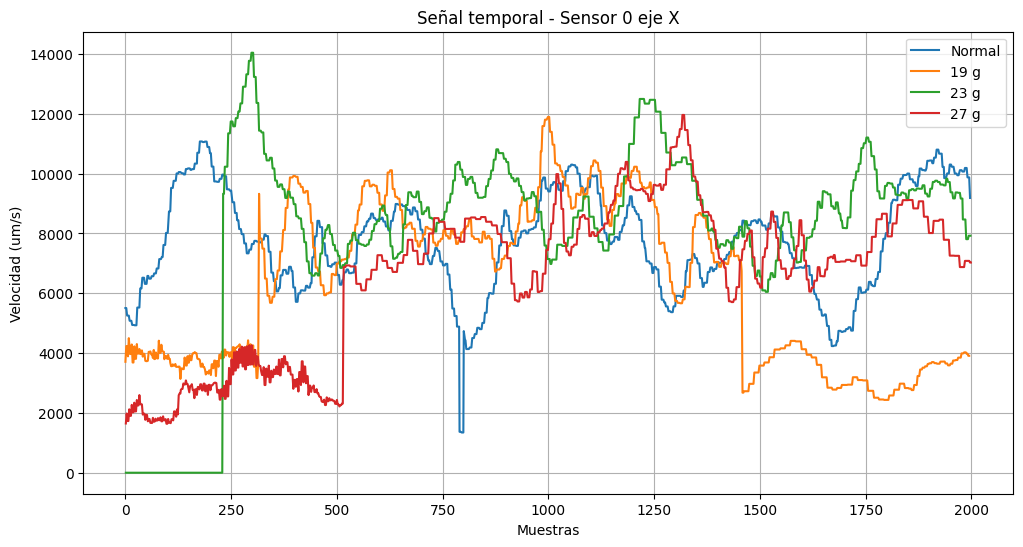

In [47]:

normal = pd.read_csv("../data/training/normal/session_20260216_212655.csv")
u19 = pd.read_csv("../data/training/unbalance_19g/session_20260216_213359.csv")
u23 = pd.read_csv("../data/training/unbalance_23g/session_20260216_220220.csv")
u27 = pd.read_csv("../data/training/unbalance_27g/session_20260216_220915.csv")

normal = normal[normal["sensor_id"] == 0]
u19 = u19[u19["sensor_id"] == 0]
u23 = u23[u23["sensor_id"] == 0]
u27 = u27[u27["sensor_id"] == 0]

plt.figure(figsize=(12,6))

plt.plot(normal["vx_um_s"][:1000], label="Normal")
plt.plot(u19["vx_um_s"][:1000], label="19 g")
plt.plot(u23["vx_um_s"][:1000], label="23 g")
plt.plot(u27["vx_um_s"][:1000], label="27 g")

plt.legend()
plt.title("Señal temporal - Sensor 0 eje X")
plt.xlabel("Muestras")
plt.ylabel("Velocidad (um/s)")
plt.grid()

plt.show()

In [48]:
fft_normal = obtener_fft(
    normal["vx_um_s"].values
)

fft_19 = obtener_fft(
    u19["vx_um_s"].values
)

fft_23 = obtener_fft(
    u23["vx_um_s"].values
)

fft_27 = obtener_fft(
    u27["vx_um_s"].values
)

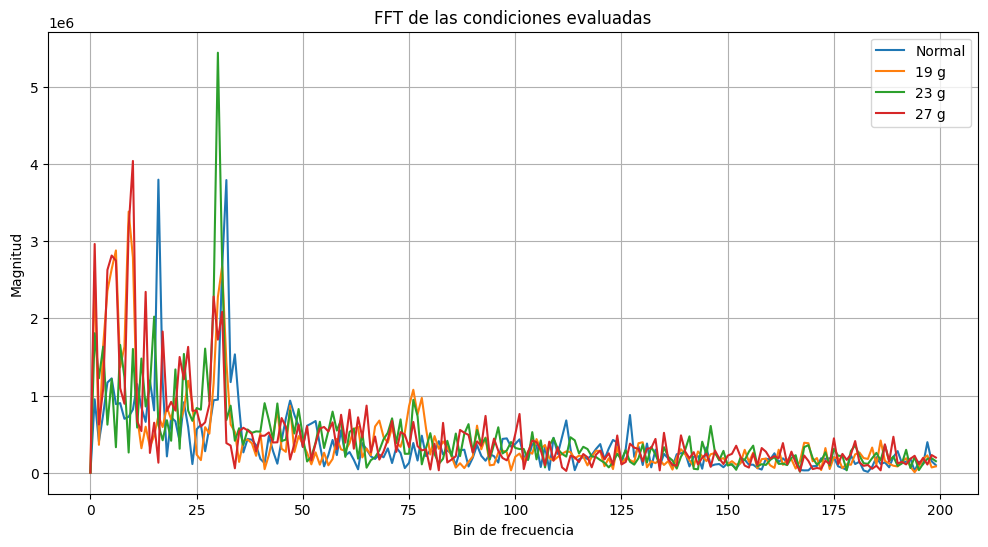

In [49]:
plt.figure(figsize=(12,6))

plt.plot(fft_normal[:200], label="Normal")
plt.plot(fft_19[:200], label="19 g")
plt.plot(fft_23[:200], label="23 g")
plt.plot(fft_27[:200], label="27 g")

plt.legend()

plt.title(
    "FFT de las condiciones evaluadas"
)

plt.xlabel("Bin de frecuencia")
plt.ylabel("Magnitud")

plt.grid()

plt.show()